# Polymath 2026 AI for Mathematical Discovery
## Team Forest Notebook
Members:
- Agastya Arora
- Cora Shaklee
- Rendi Adinata


## 0. Imports and Define draw_graph Function

In [ ]:
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import copy
from itertools import combinations
from networkx.algorithms import bipartite

In [ ]:
def draw_bipartite(adj_matrix, title="Bipartite Graph"):
    """
    Creates and displays a cleanly formatted bipartite graph from an adjacency matrix.
    Uses 1-based indexing (1 to n for left, n+1 to v for right).

    Parameters:
    adj_matrix (list of lists or numpy array): A square adjacency matrix.
    title (str): Title of the plot.
    """
    # 1. Convert the input matrix to a NumPy array and initialize the graph
    matrix = np.array(adj_matrix)
    G = nx.from_numpy_array(matrix)

    # 2. Verify the graph is actually bipartite
    if not bipartite.is_bipartite(G):
        raise ValueError("The provided adjacency matrix does not form a bipartite graph.")

    # 3. Automatically sort nodes into left and right sets
    node_colors = bipartite.color(G)
    left_nodes = [node for node, color in node_colors.items() if color == 0]
    right_nodes = [node for node, color in node_colors.items() if color == 1]

    # 4. Create a custom label mapping dictionary
    labels = {}
    current_label = 1

    # Label the first partition (1 to n)
    for node in sorted(left_nodes):
        labels[node] = current_label
        current_label += 1

    # Label the second partition (n+1 to v)
    for node in sorted(right_nodes):
        labels[node] = current_label
        current_label += 1

    # 5. Compute the bipartite layout
    pos = nx.bipartite_layout(G, left_nodes)

    # 6. Render the graph with a clean white background
    plt.figure(figsize=(8, 6), facecolor='white')

    # Apply the uniform style and inject the custom labels
    nx.draw(
        G,
        pos,
        labels=labels,           # Use our new 1-based labels
        with_labels=True,
        node_color="lightblue",  # Uniform light blue
        node_size=400,           # Scaled down for snug fit
        edge_color="black",      # Standard black edges
        width=1.0,               # Thinner lines
        font_color="black"       # Black text
    )

    plt.title(title, fontsize=14, pad=20)
    plt.show()

## 1. Preliminaries

### Bipartite Graph

A graph $G = (V, E)$ is **bipartite** if we can write $V= V1 \sqcup V2$ ( $⊔$ means a disjoint union) where $V_1$ and $V_2$ are both nonempty vertex sets of G, and every edge $e \in E$ has one endpoint in $V_1$ and the other in $V_2$. One key property of bipartite graph is that it has no odd cycles.



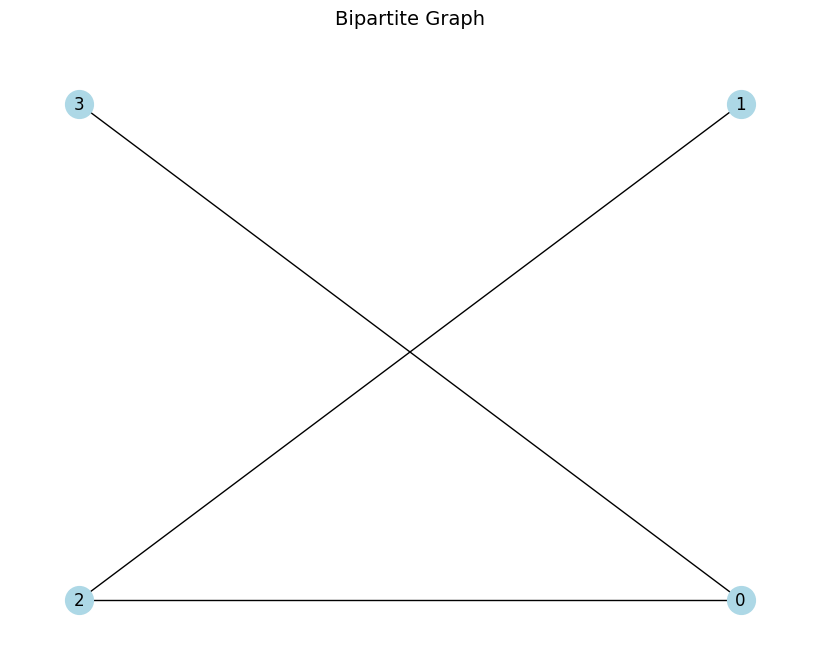

In [ ]:
# Example of bipartite graph
# Adjacency matrix for a simple bipartite graph
# Nodes 0, 1 are in one set; Nodes 2, 3 are in the other.
example_matrix = [
    [0, 0, 1, 1],
    [0, 0, 1, 0],
    [1, 1, 0, 0],
    [1, 0, 0, 0]
]

draw_bipartite(example_matrix, title="Bipartite Graph")


### Trees
A **tree** is a **connected** and **acyclic** graph.
### Forest

A **forest** is a graph $G = (V, E)$ that is **acyclic**. Equivalently, a forest is a disjoint union of trees.





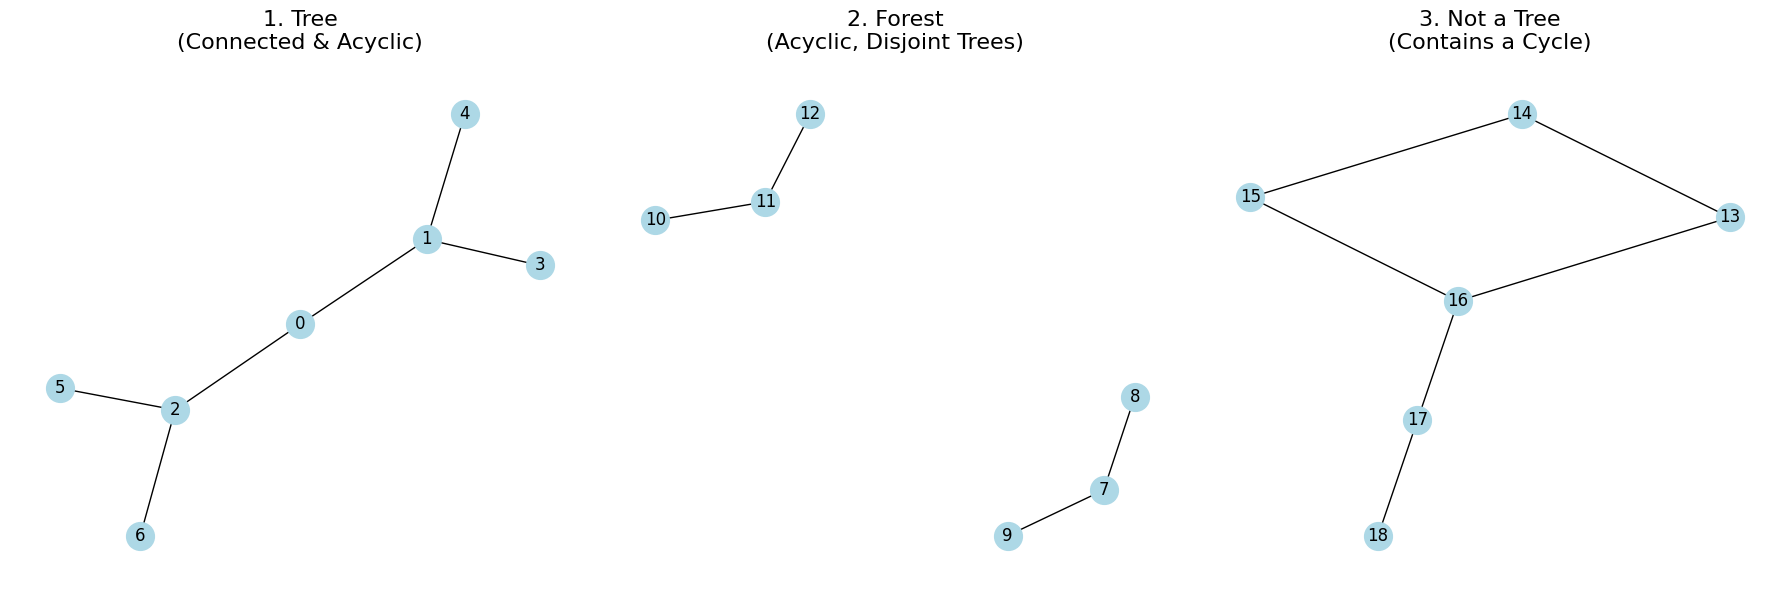

In [ ]:
# @title
# Set up a high-quality figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white') # Clean white background matching image_77c425.png

# Styling parameters based on the reference image
style = {
    'with_labels': True,
    'node_size': 400,          # Scaled down so numbers fit snugly
    'node_color': 'lightblue', # Uniform light blue color for all nodes
    'font_size': 12,
    'font_color': 'black',     # Black text for numbers
    'width': 1.0,              # Thinner lines
    'edge_color': 'black'      # Black edges
}

# ==========================================
# 1. A Tree (Connected and Acyclic)
# ==========================================
# Generating a balanced binary tree (Defaults to nodes 0-6)
T = nx.balanced_tree(r=2, h=2)

pos_T = nx.spring_layout(T, seed=42, k=0.5)

nx.draw(T, pos_T, ax=axes[0], **style)
axes[0].set_title('1. Tree\n(Connected & Acyclic)', fontsize=16, pad=15)

# ==========================================
# 2. A Forest (Disconnected and Acyclic)
# ==========================================
# Creating a graph with two disjoint trees, updated to use numbers
F = nx.Graph()
F.add_edges_from([
    (7, 8), (7, 9),    # Tree component 1
    (10, 11), (11, 12) # Tree component 2
])

pos_F = nx.spring_layout(F, seed=10, k=0.9)

nx.draw(F, pos_F, ax=axes[1], **style)
axes[1].set_title('2. Forest\n(Acyclic, Disjoint Trees)', fontsize=16, pad=15)

# ==========================================
# 3. Not a Tree (Contains a Cycle)
# ==========================================
# Creating a graph with a loop/cycle, updated to use distinct numbers
G = nx.Graph()
G.add_edges_from([
    (13, 14), (14, 15), (15, 16), (16, 13), # Cycle
    (16, 17), (17, 18)                      # Attached branch
])

pos_G = nx.kamada_kawai_layout(G)

nx.draw(G, pos_G, ax=axes[2], **style)
axes[2].set_title('3. Not a Tree\n(Contains a Cycle)', fontsize=16, pad=15)

# Final rendering adjustments
plt.tight_layout()
plt.show()

### Log-Concave

A sequence of non-negative real numbers $(a_i)_{i \in I}$ is log-concave if $a_i^2 \ge a_{i-1}a_{i+1}$ for all indices $i$ such that $i-1, i, i+1 \in I$.

### PaternBoost

In our project, we will implement Pattern Boost V2 for our problem which you can access [here]([here](https://github.com/AxiomMath/axplorer). We're not going to run Pattern Boost here, but the code in this notebook will demonstrate our approach.


#### What is PatternBoost?

PatternBoost is a transformer-based (like the "T" in "ChatGPT") AI architecture.

The method involves an iterative alternation between "local" and "global". The former is typically a simple greedy algorithm. The latter is a form of genetic algorithm using a transformer. To get the sense of how this iteration might look, consider an example of a collective human endeavor, the design of bicycles. The "local" step involves many individual bicycle-makers each making a sequence of careful tweaks to their design, trying to make it as efficient and comfortable as possible.
The "global" step involves people living in the world, seeing lots of bicycles around, each one of which has been carefully optimized locally, and then developing a new bicycle design based on those they have observed. Of course this new design would then be carefully optimized by both its designer and others; and if after those tweaks, the new bikes turned out to be notably comfortable and efficient, a lot of them would be sold, and they would join the general fleet of bicycles observed by the next prospective designer,... and on and on we go.



In practice, writing an algorithm for PatternBoost requires 3 separate processes:

1. **Object Representation:** Representing your objects of study in a way that the computer can process (e.g., a graph could be represented as a flattened adjacency matrix).

2. **Local Optimization:** Writing a local optimization algorithm (normally a greedy or naïve heuristic).
3. **Scoring Function:** Providing a scoring function for the architecture to measure its success.

A successful program will depend heavily on all of the choices made in these three steps.

## 2. Problem Statement

Let $G=(V,E)$ be a graph with $|V|=n$ . Define $f_{i}(G)$ to be the **number of vertex subsets of G with size i** where the induced subgraph is a **forest**. We write $\{f_{i}(G)\}_{i=1}^{n}$ to be the sequence built from it. We would like to determine whether this sequence is **log concave** if G is a **bipartite graph**.  

## 3. Our Approach

Here we will breakdown our approach for the 3 steps to implement PatternBoost mentioned above.

### Choosing Representation




We start by choosing a representation for our bipartite graph. We use **adjacency matrix** or **adjacency list** (whenever convenient) to represent our graph. However, since PatternBoost can only process string, we will have to convert the adj. matrix to string.  


We code the following function to convert our bipartite graph's adjacency matrix into a string.

#### create_string_rep()

In [ ]:
def create_string_rep(n,G):
  '''
  Args:
    n: The cutoff index (determines which rows to process and which columns to skip).
    G: The input 2D array (matrix).

  Outputs:
    string_rep: A string representation of the adjacency matrix.
  '''
  string_rep = [n]
  count1=1
  for row in G:
      count2=1
      if count1<=n:
          for y in row:
              if count2>n:
                  string_rep.append(y)
              count2+=1
      count1+=1
  return string_rep
'''
Example:
G = [[0,0,1,1,1],
     [0,0,0,1,1],
     [1,0,0,0,0],
     [1,1,0,0,0],
     [1,1,0,0,0]]
n=2
#input size of matrix
print(create_string_rep(n,G))

Output: [2, 1, 1, 1, 0, 1, 1]
'''


'\nG = [[0,0,1,1,1],\n     [0,0,0,1,1],\n     [1,0,0,0,0],\n     [1,1,0,0,0],\n     [1,1,0,0,0]]\nn=2\n#input size of matrix\nprint(create_string_rep(n,G))\n\nOutput: [2, 1, 1, 1, 0, 1, 1]\n'

This function extracts a specific block of elements from a matrix `G` and flattens them into a 1D list, using `n` as a prefix. Specifically, it captures the elements from the **first `n` rows** that are located **after the `n`-th column**.

**Walkthrough:** \
Given a 5x5 matrix `G` and `n = 2`:

1. The code only processes the **first 2 rows**.
2. Within those rows, it ignores the **first 2 columns**.
3. It collects the remaining elements row by row:
   * **Row 1:** skips `[0, 0]`, collects `1, 1, 1`
   * **Row 2:** skips `[0, 0]`, collects `0, 1, 1`
4. Finally, it prepends the value of `n` (2) to the collected elements.

**Expected Output:**
`[2, 1, 1, 1, 0, 1, 1]`

For this representation to successfully represent any bipartite graph (making it effectively **surjective** up to isomorphism), we make the following assumptions:
*   **Vertex Relabeling:** Assume the freedom to relabel (reorder) the vertices of any given bipartite graph so that all nodes in the first partition are indexed $0$ to $n-1$, and all nodes in the second partition are indexed $n$ to $V-1$.
*   **Known Partition Size ($n$):** Assume the integer $n$ (extracted from the front of our string) correctly identifies the size of one of the two partition

It can be shown that this procedure produces **unique (injective)** string representation up to graph isomorphism.

Note:
- At this point, we treat the string as a list of char because it's easier to deal with prefix number that has digit more than 1 (i.e 10, etc).


We also code function to convert a string back to the graph's adjacency matrix.

#### create_matrix()

In [ ]:
def create_matrix(vertices, string):
    '''
    Args:
      vertices: number of vertices that the graph has.
      string: A list/string representation of the adjacency matrix.

    Outputs:
      G: the adjacency matrix of graph G.
    '''
    # Extract n from the beginning of the string/list
    n = int(string[0])

    # Initialize zero matrix
    G = [[0 for _ in range(vertices)] for _ in range(vertices)]

    # Start reading edge data from index 1 (since index 0 is n)
    CountStringItem = 1

    for x in range(n):
        CountColumn = n
        for z in G[x][n:]:
            G[x][CountColumn] = int(string[CountStringItem])
            CountStringItem += 1
            CountColumn += 1

    # Mirror the top-right block to the bottom-left to maintain symmetry
    for i in range(n):
        for j in range(vertices):
            G[j][i] = G[i][j]

    return G

This is basically just doing the inverse of previous procedure to fill the upper right triangle of the matrix, and then make it a symmetric matrix. Next, we code a function to generate a random (valid) list representation that will translate to adjacency matrix of a bipartite graph.

#### generate_list()

In [ ]:
def generate_list(n):
    '''
  Args:
   n: The cutoff index (determines which rows to process and which columns to skip).

  Outputs:
    lst: A list representation of the adjacency matrix.
  '''
    NumOfVertices=n
    NumOfRows=random.randint(1,NumOfVertices-1) # number of rows of the block
    NumOfCol=NumOfVertices-NumOfRows # number of columns in the block
    NumOfElements=NumOfCol*NumOfRows #in the block
    #print(NumOfRows)
    lst=[]

    for i in range(NumOfElements):
        a=random.randint(0,1)
        conv=str(a)
        lst.append(conv)

    conv=str(NumOfRows)
    lst.append(conv)
    return(lst)

#### Example

Here's a quick example:

In [ ]:
vertices = int(input('Enter number of Vertices: '))
l = generate_list(vertices)
M = create_matrix(vertices,l) # don't worry, python can treat list of chars as string
for x in M:
    print(x)

Enter number of Vertices: 3
[0, 0, 1]
[0, 0, 0]
[1, 0, 0]


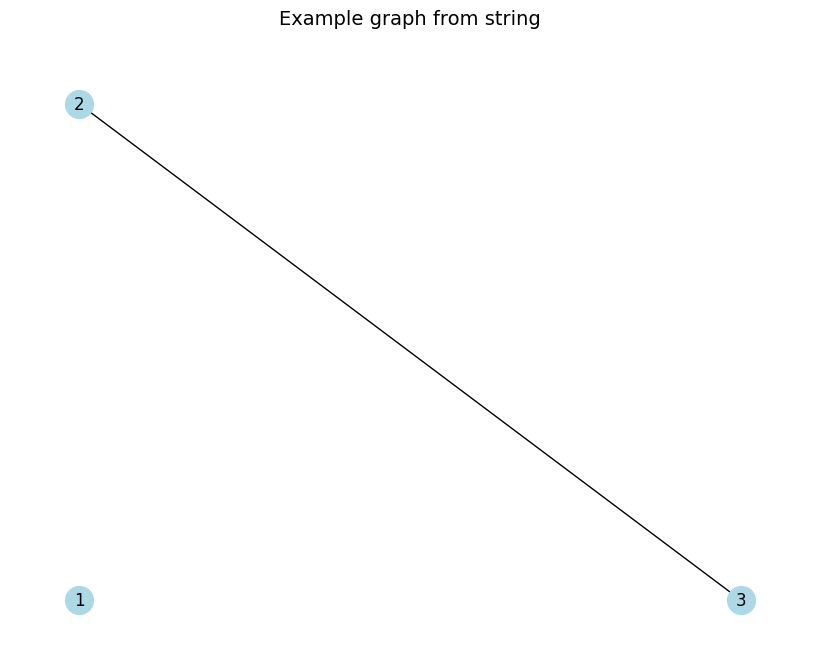

In [ ]:
draw_bipartite(M, title="Example graph from string")

#### is_legal_list()

In [ ]:
def is_legal_list(lst):
    '''
  Args:
    lst: A list representation of the adjacency matrix.
  Outputs:
    (bool): True if the lst is valid and false otherwise.
  '''
    print(lst)
    NumOfRows=lst.pop(0) #removes first element from the list
    if len(lst)%NumOfRows!=0:
        return False
    for i in lst:
        if i!=0 or i!=1:
            return False
    return True

This is a validator function just in case the generated list from our code (or PatternBoost) is not valid (doesn't translate to a bipartite graph).

### Scoring Function

Based on our representation for the bipartite graphs, we can start constructing our scoring function. For the scoring function, we will have to code a function to calculate $f_i(G)$, and then check for each consecutive triplets $i-1,i,i+1$ if they satisfiy the log concavity condition. The score of the graph will be $max_{\forall i \in I} ( f_{i-1}(G)f_{i+1}(G)-f_i(G)^2 )$ where $I=\{1, \dots,|V|\}$.

#### matrix_to_list()

First, we code a function to convert adjacency matrix to adjacency list.

In [ ]:
def matrix_to_list(adj_matrix):
    n = len(adj_matrix)

    # init empty list
    adj_list = [[] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            #Append only the neighbor
            if adj_matrix[i][j] != 0:
                adj_list[i].append(j)

    return adj_list

Because we want to count only subgraphs of G that are forests, we need a function to check if an induced subgraph of a particular vertex set of size $i$ is a forest or not (using its adjacency list).  

In [ ]:
def find_cycle(A):
    """
    Checks if there's a cycle in a general undirected graph.

    Args:
        A: Adjacency matrix of the graph.

    Returns:
        bool: True if a cycle exists, False otherwise.
    """
    adj_list = matrix_to_list(A)
    n = len(adj_list) # num of vertices
    visited = [False] * n   # to mark visited vertex

    def dfs(u, parent):
        visited[u] = True #current vertex marked as visited
        for v in adj_list[u]:
            if not visited[v]: # if adjacent vertex has not been visited
                if dfs(v, u): # if adjacent vertex is visited
                    return True # cycle found
            elif v != parent: # if adjacent vertex is visited and not parent
                return True # cycle found
        return False

    for i in range(n): # iterate over all vertices
        if not visited[i]:
            if dfs(i, -1): # if cycle found
                return True

    return False

We use DFS to traverse through the graph. The idea here is that if we can find 2 different paths between 2 different vertices in the graph, then it contains a cycle.

In [ ]:
def get_all_vertex_subsets_of_size_i(n,i): #n=no. of vertices, i=size of the vertex-subset we are looking at
    subset_list=list(combinations(range(0,n),i))
    return subset_list

In [ ]:
def get_minor(A,n,i):#the size of vertex subset we are looking at
    lst=get_all_vertex_subsets_of_size_i(n,i)
    all_minors=[]
    for i in lst: #lst is the list of all combinations
        VertexSubset=list(i) # VertexSubset is just one combination
        newA = copy.deepcopy(A)
        for index in VertexSubset:
            index-=1
            newA[index] = [0]*n
            for row in newA:
                row[index] = 0
        all_minors.append(newA)
    return all_minors

In [ ]:
#Currently only finds consecutive submatrices
matrix = [
    [3, 5, 1, 3],
    [2, 4, 7, 5],
    [8, 0, 9, 2],
    [2, 1, 5, 0]
]
n=len(matrix)
i=3
for x in range(n - i + 1):
    for t in range(n - i + 1):
        new = [row[t:t+i] for row in matrix[x:x+i]]
        print(new)

In [ ]:
#Set number of examples to generate and number of vertices
vertices = 5
NumExamples = 1
for x in range(NumExamples):
    l = generate_list(vertices)
    matrix = create_matrix(vertices,l) #random graph
    print(matrix)
    for i in range(2,vertices):
        LogConcaveStatus = True
        l = []
        for y in range(i-1,i+2):
            all_minors = get_minor(matrix,vertices,y)
            NumCollections = 0 #Counts number of valid sub forests for y vertices
            for minor in all_minors:
                cycle_status = find_cycle(minor)
                if not cycle_status:
                    NumCollections += 1 #Adds if no cycle is found
            l.append(NumCollections) #creates list of number of forests for i-1 to i+1
        if not((l[1])*(l[1]) >= l[0]*l[2]): #Check log concavity
            LogConcaveStatus = False
    print(LogConcaveStatus)

[[0, 0, 0, 1, 0], [0, 0, 0, 0, 1], [0, 0, 0, 0, 0], [1, 0, 0, 0, 0], [0, 1, 0, 0, 0]]


TypeError: 'list' object is not callable

### Local Search

# References

- Fran¸cois Charton, Jordan S Ellenberg, Adam Zsolt Wagner, and Geordie Williamson. Patternboost:
Constructions in mathematics with a little help from ai. arXiv preprint arXiv:2411.00566, 2024.
- PatternBoost V2: https://github.com/AxiomMath/axplorer
- TeamForest Repo: https://github.com/agastya-arora/TeamForest